In [ ]:
import os

# jax device and parallelization flags on m4 mac.
# modify as needed.
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=12"

import sys
sys.path.append('../../src/')

import numpy as onp
import jax
import jax.numpy as jnp
from jax.scipy.special import logsumexp

from myutils_corrected import Ntime, ACFs, set_detectors, set_detector_locations
from myutils_corrected import ln_likelihood_full_jit, ln_likelihood_full, Ntime, ACFs

from scipy.linalg import toeplitz, solve_triangular
import scipy.signal as sig

import lal
from gwpy.timeseries import TimeSeries
from other_utils import bandpass_ds, analysis_data, interp1d_jax, load_tables

jax.config.update("jax_enable_x64", True) 

/Users/kallol/Work/Misc/ringdown__2/examples/max-sky/../../src/myutils_corrected.py:3: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from corner import corner
from chainconsumer import Chain, ChainConsumer, Truth, ChainConfig, PlotConfig

import h5py

import numpyro
from numpyro.infer import MCMC, NUTS
from numpyro.contrib.nested_sampling import NestedSampler
import numpyro.distributions as dist
numpyro.enable_x64()

/Users/kallol/miniconda3/envs/skyloc_ringdown/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
plt.rcParams["axes.grid"] = False

# Data download parameters

In [ ]:
tgps = 1420878141.235932 
tM = 0.337e-3 
tgps = tgps + 6*tM

seglen = 8
fs = 16384
fmin = 30
fmax       = 1500
event_id = "GW250114"
plot_checks = 0
T = 0.2
srate = 4096

ra = 2.33
dec = 0.190
psi = 1.329

factor = 10
seed       = 31567
t0         = 0.0

qnm1_path  = "../../data/l2/n1l2m2.dat"
qnm2_path  = "../../data/l2/n2l2m2.dat"

In [5]:
dH1 = TimeSeries.fetch_open_data('H1', tgps - seglen/2, tgps + seglen/2, sample_rate=fs)
dL1 = TimeSeries.fetch_open_data('L1', tgps - seglen/2, tgps + seglen/2, sample_rate=fs)

In [6]:
n_analyze = Ntime(srate, T)

delays = {}
tgps_ = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps_)
dt_ifo = delays.get('H1',
                    lal.TimeDelayFromEarthCenter(lal.CachedDetectors[lal.LALDetectorIndexLHODIFF].location, ra, dec, tgps))
tH1 = tgps + dt_ifo

delays = {}
tgps_ = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps_)
dt_ifo = delays.get('L1',
                    lal.TimeDelayFromEarthCenter(lal.CachedDetectors[lal.LALDetectorIndexLLODIFF].location, ra, dec, tgps))
tL1 = tgps + dt_ifo


dH1_cond = bandpass_ds(dH1, t0=tH1, ds=int(fs/srate), trim=0.25, f_min=fmin)
dL1_cond = bandpass_ds(dL1, t0=tH1, ds=int(fs/srate), trim=0.25, f_min=fmin)


nperseg = int(seglen * (1/(dH1.times.value[1] - dH1.times.value[0])))
noverlap = nperseg // 2

psdH = sig.welch(
    dH1.value,
    fs=fs,
    window="hann",
    nperseg=4096*4,
    noverlap=4096*2,
    detrend=False,
    return_onesided=True,
    scaling="density",    
)

psdL = sig.welch(
    dL1.value,
    fs=fs,
    window="hann",
    nperseg=4096*4,
    noverlap=4096*2,
    detrend=False,
    return_onesided=True,
    scaling="density",     
)

In [44]:
print('H1 time: ', tH1)
print('L1 time: ', tL1)

H1 time:  1420878141.221026
L1 time:  1420878141.2185555


In [ ]:

dt_np = 1.0 / srate
Nt     = Ntime(srate=srate, T=T)
freqs_np = onp.fft.rfftfreq(Nt, d=dt_np)

fmin_eff = freqs_np[0]  if (fmin is None) else float(fmin)
fmax_eff = freqs_np[-1] if (fmax is None) else float(fmax)

i0 = int(onp.searchsorted(freqs_np, fmin_eff, side="left"))
i1 = int(onp.searchsorted(freqs_np, fmax_eff, side="right"))

freqs = jnp.asarray(freqs_np, dtype=jnp.float64)

# Prior limits
limits = [
    [55.0, 95.0],
    [0., 0.99],
    [0., 4.0],
    [0., 6.283185307179586],
    [0., 4.0],
    [0., 6.283185307179586],
    [-1., 1.],
    [0., 3.141592653589793]]

low  = onp.asarray([pair[0] for pair in limits], dtype=onp.float64)
high = onp.asarray([pair[1] for pair in limits], dtype=onp.float64)

In [8]:
psdH = interp1d_jax(jnp.asarray(psdH[0],dtype=jnp.float64), jnp.asarray(psdH[1],dtype=jnp.float64))
psdL = interp1d_jax(jnp.asarray(psdL[0],dtype=jnp.float64), jnp.asarray(psdL[1],dtype=jnp.float64))

omega_r, omega_i, omega_OT_r, omega_OT_i = load_tables(qnm1_path, qnm2_path)
tgps = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps)

rhoH, rhoL = ACFs(srate=srate, T=T, psdH=psdH, psdL=psdL, factor=factor)
covH=toeplitz(rhoH)
covL=toeplitz(rhoL)
L_H=jnp.linalg.cholesky(covH)
L_L=jnp.linalg.cholesky(covL)

resp_H_py = lal.CachedDetectors[lal.LALDetectorIndexLHODIFF].response
resp_L_py = lal.CachedDetectors[lal.LALDetectorIndexLLODIFF].response
resp_H = jnp.asarray(resp_H_py, dtype=jnp.float64)
resp_L = jnp.asarray(resp_L_py, dtype=jnp.float64)

set_detectors(resp_H, resp_L)

H1 = lal.CachedDetectors[lal.LALDetectorIndexLHODIFF]
L1 = lal.CachedDetectors[lal.LALDetectorIndexLLODIFF]

rH = jnp.array([H1.location[0], H1.location[1], H1.location[2]], dtype=jnp.float64)
rL = jnp.array([L1.location[0], L1.location[1], L1.location[2]], dtype=jnp.float64)

set_detector_locations(rH, rL)

In [ ]:
# data strain starting from tH1 in both H1 and L1 for the Full-sky analysis
dH1_analysis_data = analysis_data(dH1_cond[1], dH1_cond[0], tH1, n_analyze)
dL1_analysis_data = analysis_data(dL1_cond[1], dL1_cond[0], tH1, n_analyze)

h_H_t = dH1_analysis_data[1]
h_L_t = dL1_analysis_data[1]

In [ ]:
with h5py.File("../GW250114_posterior_samples_NRSur7dq4.h5", "r") as f:
    post_samples = f['bilby-NRSur7dq4_prod-reweighted']['posterior_samples'][:]

cosi_imr = onp.cos(post_samples['iota'])
ra_imr = post_samples['ra']
sindec_imr = onp.sin(post_samples['dec'])
psi_imr = post_samples["psi"]


ext_post = onp.array([ra_imr, sindec_imr]).T

logl_post = jnp.array(post_samples['log_likelihood'])
logp_post = jnp.array(post_samples['log_prior'])
log_post = logl_post + logp_post

In [19]:
# from corner import corner
# nsamp = 100
# idxs = onp.random.randint(low=0, high=len(ext_post), size=nsamp)
# fig = corner(onp.asarray(ext_post), bins=40, labels=['cosi', 'ra', 'dec', 'psi'], hist_kwargs={'density': 1}, plot_datapoints=0)
# corner(onp.asarray(ext_post[idxs]), bins=40, fig=fig, labels=['cosi', 'ra', 'dec', 'psi'], color='r', hist_kwargs={'density': 1}, plot_datapoints=0)
# plt.show()

In [20]:
nsamp = 100
idxs = onp.random.randint(low=0, high=len(ext_post), size=nsamp)
ext_mc_integ = ext_post[idxs]
log_post_mc_integ = log_post[idxs]

In [24]:
def make_logw_normalized(log_p_phi, log_q_phi):
    logw = log_p_phi - log_q_phi                     
    logw = logw - logsumexp(logw)                    
    return logw                                      

logw = make_logw_normalized(0.0, logl_post)
logw_mc_integ = logw[idxs]

In [25]:
def make_loglik_fn(dataH, dataL, gmst, L_H, L_L,
                   omega_r, omega_i, omega_OT_r, omega_OT_i,
                   T, srate, t0):
    def _loglik(theta):
        return ln_likelihood_full_jit(
            dataH=dataH, dataL=dataL, params=theta,
            gmst=gmst, L_H=L_H, L_L=L_L,
            omega_r=omega_r, omega_i=omega_i,
            omega_OT_r=omega_OT_r, omega_OT_i=omega_OT_i,
            T=T, srate=srate, t0=t0
        )
    return _loglik

loglik_fn = make_loglik_fn(
    dataH=h_H_t, dataL=h_L_t,
    gmst=gmst, L_H=L_H, L_L=L_L,
    omega_r=omega_r, omega_i=omega_i,
    omega_OT_r=omega_OT_r, omega_OT_i=omega_OT_i,
    T=T, srate=srate, t0=t0
)

def loglike(theta_free):
    theta_free_batched = jnp.broadcast_to(theta_free, (nsamp, theta_free.shape[0]))  

    thetas_batched = jnp.concatenate(
                                    [
                                        theta_free_batched[:, :7],          
                                        ext_mc_integ,             
                                        theta_free_batched[:, 7:8],       
                                    ],
                                    axis=1,
                                )

    logliks = jax.vmap(loglik_fn)(thetas_batched)
    return logsumexp(logliks + logw_mc_integ)

In [27]:
low  = jnp.asarray(low,  dtype=jnp.float64)
high = jnp.asarray(high, dtype=jnp.float64)

def model_informed_sky():
    theta_free = numpyro.sample("theta", dist.Uniform(low, high))  
    numpyro.factor("loglike", loglike(theta_free))


In [28]:
rng_key = jax.random.PRNGKey(int(seed) ^ 0xABCDEF)
rng_run, rng_post = jax.random.split(rng_key)
ns_informed_sky = NestedSampler(
    model_informed_sky,
    constructor_kwargs=dict(
        num_live_points=10000,    
        max_samples=500_000,      
        verbose=True,
    ),
    termination_kwargs=dict(
        dlogZ=0.01,               
    ),
)
ns_informed_sky.run(rng_run)
ns_informed_sky.print_summary()
posterior_informed_sky = ns_informed_sky.get_samples(rng_post, num_samples=100_000)

INFO:jaxns:Number of Markov-chains set to: 10000


Running over 12 devices.
Creating initial state with 10008 live points.
Running uniform sampling down to efficiency threshold of 0.1.
Running until termination condition: TerminationCondition(ess=None, evidence_uncert=None, live_evidence_frac=None, dlogZ=Array(0.01, dtype=float64, weak_type=True), max_samples=Array(500400, dtype=int64), max_num_likelihood_evaluations=None, log_L_contour=None, efficiency_threshold=None, rtol=None, atol=None, peak_XL_frac=None)
-------
Num samples: 5004
Num likelihood evals: 240774
Efficiency: 0.04071967385201279
log(L) contour: -1857.7872663996375
log(Z) est.: -748.1637891172443 +- 0.828790361772149
log(Z | remaining) est.: 1119.0363353498537 +- 1.0004270988096564
ESS: 0.5062873047023099

-------
Num samples: 10008
Num likelihood evals: 524125
Efficiency: 0.024641870497220157
log(L) contour: -1079.570773531078
log(Z) est.: -746.9836100371284 +- 0.7179813600024395
log(Z | remaining) est.: 340.5733384780875 +- 0.7521710066087297
ESS: 0.741321824444567

--

2026-04-28 11:27:56.051349: E external/xla/xla/service/rendezvous.cc:100] [id=0] This thread has been waiting for `all gather RendezvousKey{run_id=RunId: 1694779187, global_devices=[0,1,2,3,4,5,6,7,8,9,10,11], num_local_participants=12, collective_op_kind=cross_module, op_id=1}` for 5 seconds and may be stuck. Expected 12 threads to join the rendezvous, but not all of them arrived on time.
2026-04-28 11:28:09.260326: E external/xla/xla/service/rendezvous.cc:110] Thread is unstuck! Warning above was a false-positive. Perhaps the timeout is too short.


-------
Num samples: 60048
Num likelihood evals: 5752199
Efficiency: 0.007934903346883243
log(L) contour: -744.8177872670767
log(Z) est.: -738.6637998345392 +- 0.26920692053290807
log(Z | remaining) est.: 14.145345068310235 +- 0.2707248419181273
ESS: 6.696714876097376

-------
Num samples: 65052
Num likelihood evals: 6459287
Efficiency: 0.0075497147357486685
log(L) contour: -741.7556587442782
log(Z) est.: -738.2168453945777 +- 0.20395348149025372
log(Z | remaining) est.: 11.800776758732013 +- 0.20590401113104517
ESS: 11.926142562486053

-------
Num samples: 70056
Num likelihood evals: 7200180
Efficiency: 0.007199052211111775
log(L) contour: -739.1413095829978
log(Z) est.: -737.8440240364819 +- 0.2112967312638045
log(Z | remaining) est.: 9.870793562445442 +- 0.21317323995630658
ESS: 11.096714670587039

-------
Num samples: 75060
Num likelihood evals: 7973009
Efficiency: 0.006882839735332529
log(L) contour: -736.8283555108928
log(Z) est.: -737.6112595075946 +- 0.1286959223608582
log(Z | 

2026-04-28 13:26:22.175512: E external/xla/xla/service/rendezvous.cc:100] [id=0] This thread has been waiting for `all gather RendezvousKey{run_id=RunId: 1694779187, global_devices=[0,1,2,3,4,5,6,7,8,9,10,11], num_local_participants=12, collective_op_kind=cross_module, op_id=1}` for 5 seconds and may be stuck. Expected 12 threads to join the rendezvous, but not all of them arrived on time.
2026-04-28 13:26:22.176805: E external/xla/xla/service/rendezvous.cc:100] [id=1] This thread has been waiting for `all gather RendezvousKey{run_id=RunId: 1694779187, global_devices=[0,1,2,3,4,5,6,7,8,9,10,11], num_local_participants=12, collective_op_kind=cross_module, op_id=1}` for 5 seconds and may be stuck. Expected 12 threads to join the rendezvous, but not all of them arrived on time.
2026-04-28 13:26:34.784848: E external/xla/xla/service/rendezvous.cc:110] Thread is unstuck! Warning above was a false-positive. Perhaps the timeout is too short.
2026-04-28 13:26:34.784888: E external/xla/xla/serv

...

-------
Num samples: 170136
Num likelihood evals: 27276484
Efficiency: 0.00424452681668971
log(L) contour: -722.0878812276411
log(Z) est.: -735.8331206646287 +- 0.03401624605765239
log(Z | remaining) est.: 0.04735743854882912 +- 0.048022334192805514
ESS: 32657.766585450852



2026-04-28 16:29:14.564608: E external/xla/xla/service/rendezvous.cc:100] [id=0] This thread has been waiting for `all gather RendezvousKey{run_id=RunId: 1694779187, global_devices=[0,1,2,3,4,5,6,7,8,9,10,11], num_local_participants=12, collective_op_kind=cross_module, op_id=1}` for 5 seconds and may be stuck. Expected 12 threads to join the rendezvous, but not all of them arrived on time.
2026-04-28 16:29:14.568324: E external/xla/xla/service/rendezvous.cc:100] [id=1] This thread has been waiting for `all gather RendezvousKey{run_id=RunId: 1694779187, global_devices=[0,1,2,3,4,5,6,7,8,9,10,11], num_local_participants=12, collective_op_kind=cross_module, op_id=1}` for 5 seconds and may be stuck. Expected 12 threads to join the rendezvous, but not all of them arrived on time.
2026-04-28 16:29:14.571275: E external/xla/xla/service/rendezvous.cc:100] [id=3] This thread has been waiting for `all gather RendezvousKey{run_id=RunId: 1694779187, global_devices=[0,1,2,3,4,5,6,7,8,9,10,11], num_

-------
Num samples: 175140
Num likelihood evals: 28517076
Efficiency: 0.0041607821339141576
log(L) contour: -721.9519678740284
log(Z) est.: -735.8321080299298 +- 0.03401896632863033
log(Z | remaining) est.: 0.031644205648035495 +- 0.04805266828505284
ESS: 32869.416107443045



2026-04-28 16:46:09.721425: E external/xla/xla/service/rendezvous.cc:100] [id=0] This thread has been waiting for `all gather RendezvousKey{run_id=RunId: 1694779187, global_devices=[0,1,2,3,4,5,6,7,8,9,10,11], num_local_participants=12, collective_op_kind=cross_module, op_id=1}` for 5 seconds and may be stuck. Expected 12 threads to join the rendezvous, but not all of them arrived on time.
2026-04-28 16:46:21.633654: E external/xla/xla/service/rendezvous.cc:110] Thread is unstuck! Warning above was a false-positive. Perhaps the timeout is too short.


-------
Num samples: 180144
Num likelihood evals: 29781962
Efficiency: 0.004084834602565348
log(L) contour: -721.8383561677628
log(Z) est.: -735.8315056652013 +- 0.0340205988747006
log(Z | remaining) est.: 0.020889271824785283 +- 0.04807378781113637
ESS: 32975.15471617409

-------
Num samples: 185148
Num likelihood evals: 31069138
Efficiency: 0.004013501856565432
log(L) contour: -721.7425739955096
log(Z) est.: -735.8311867332177 +- 0.03402146721259375
log(Z | remaining) est.: 0.013625436271922808 +- 0.04808809087282962
ESS: 33025.591348438385

-------
Num samples: 190152
Num likelihood evals: 32374571
Efficiency: 0.003954202683705666
log(L) contour: -721.6589936574153
log(Z) est.: -735.8310021733826 +- 0.03402197120211353
log(Z | remaining) est.: 0.008806459751781404 +- 0.04809766418562043
ESS: 33050.37227360949

--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 32384579
samples: 200160
phantom samples: 0
likelihood evals / sample: 161.8
phantom fract

In [46]:
ns_fixed_sky._results.log_Z_mean

Array(-742.98796056, dtype=float64)

In [29]:
ns_informed_sky._results.log_Z_mean

Array(-740.4285773, dtype=float64)

In [30]:
event_id = "GW250114"

posterior_full_sky  = onp.load('../full-sky/posterior.' + event_id + '.full-sky.npy')
posterior_fixed_sky = onp.load('../fixed-sky/posterior.' + event_id + '.fixed-sky.npy')

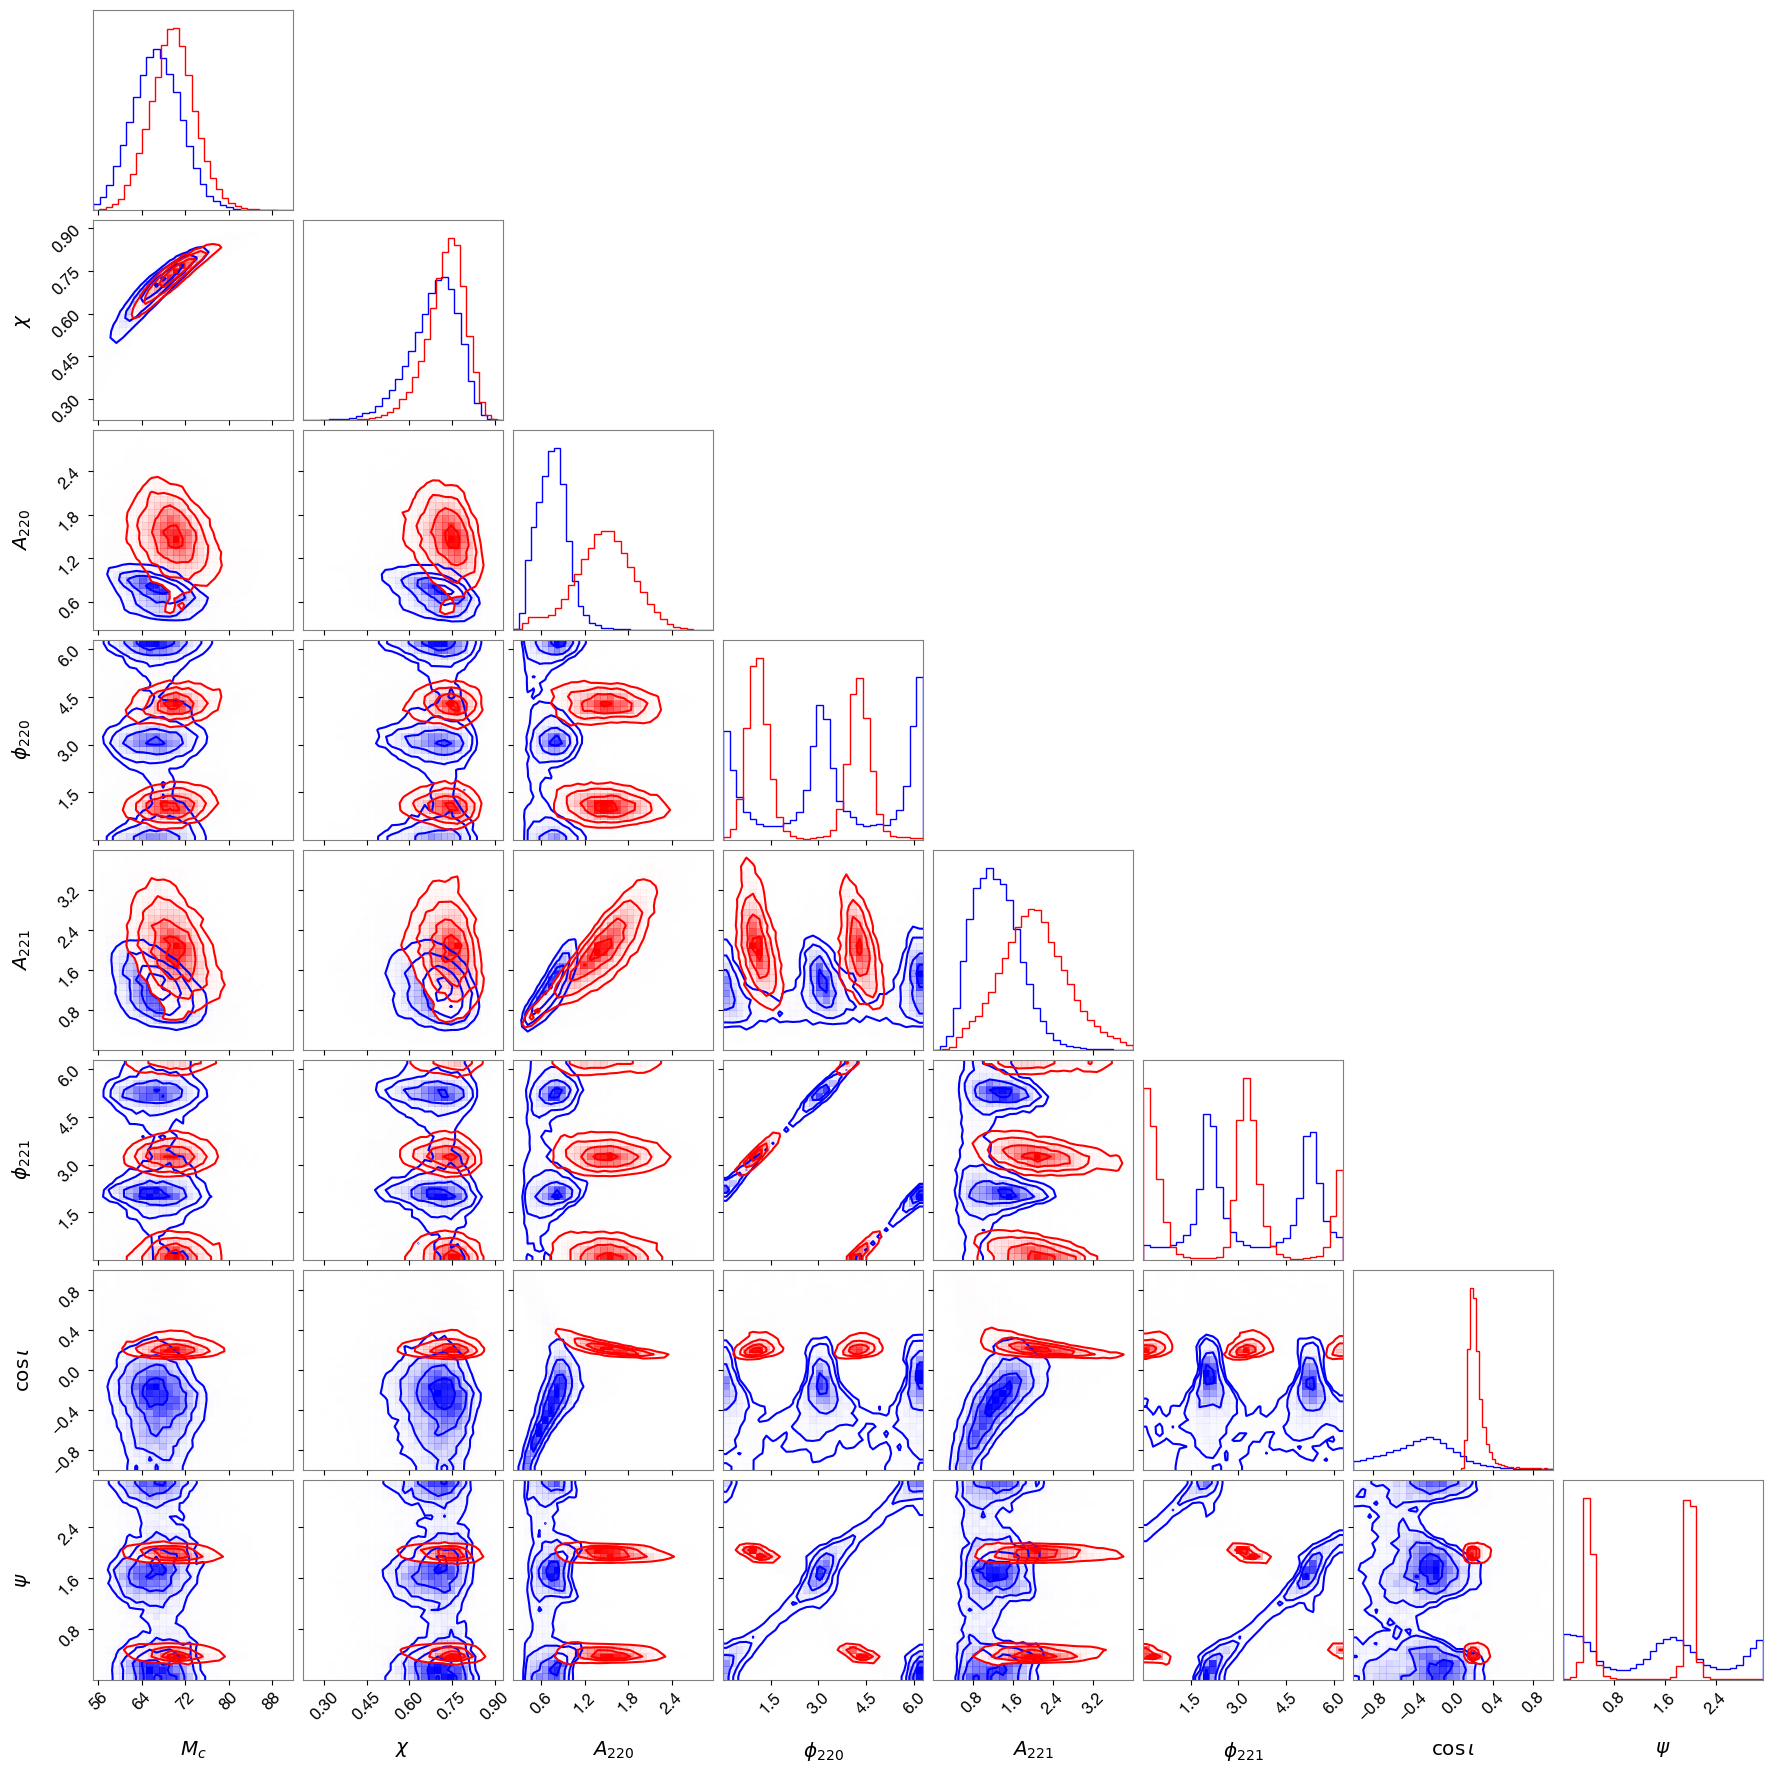

In [31]:
labels = [r'$M_c$', r'$\chi$', r'$A_{220}$', r'$\phi_{220}$', r'$A_{221}$', r'$\phi_{221}$', r'$\cos\iota$', r'$\psi$']
fig = corner(onp.asarray(posterior_informed_sky['theta']), bins=30, color='b', labels=labels, plot_datapoints=0, hist_kwargs={'density':1})
# corner(onp.asarray(posterior_max_sky['theta'][3]), bins=30, fig=fig, color='g', labels=labels, plot_datapoints=0, hist_kwargs={'density':1})
corner(posterior_fixed_sky[:,:], bins=30, fig=fig, color='r', labels=labels, plot_datapoints=0, hist_kwargs={'density':1})
plt.show()

In [35]:
onp.save('posterior.' + event_id + '.informed-sky.npy', onp.asarray(posterior_informed_sky['theta']))

In [32]:
with h5py.File("../GW250114_posterior_samples_NRSur7dq4.h5", "r") as f:
    post_samples = f['bilby-NRSur7dq4_prod-reweighted']['posterior_samples'][:]

cosi_imr = onp.cos(post_samples['iota'])
ra_imr = post_samples['ra']
sindec_imr = onp.sin(post_samples['dec'])
psi_imr = post_samples["psi"]


samples_IMR = onp.array([cosi_imr, ra_imr, sindec_imr, psi_imr]).T

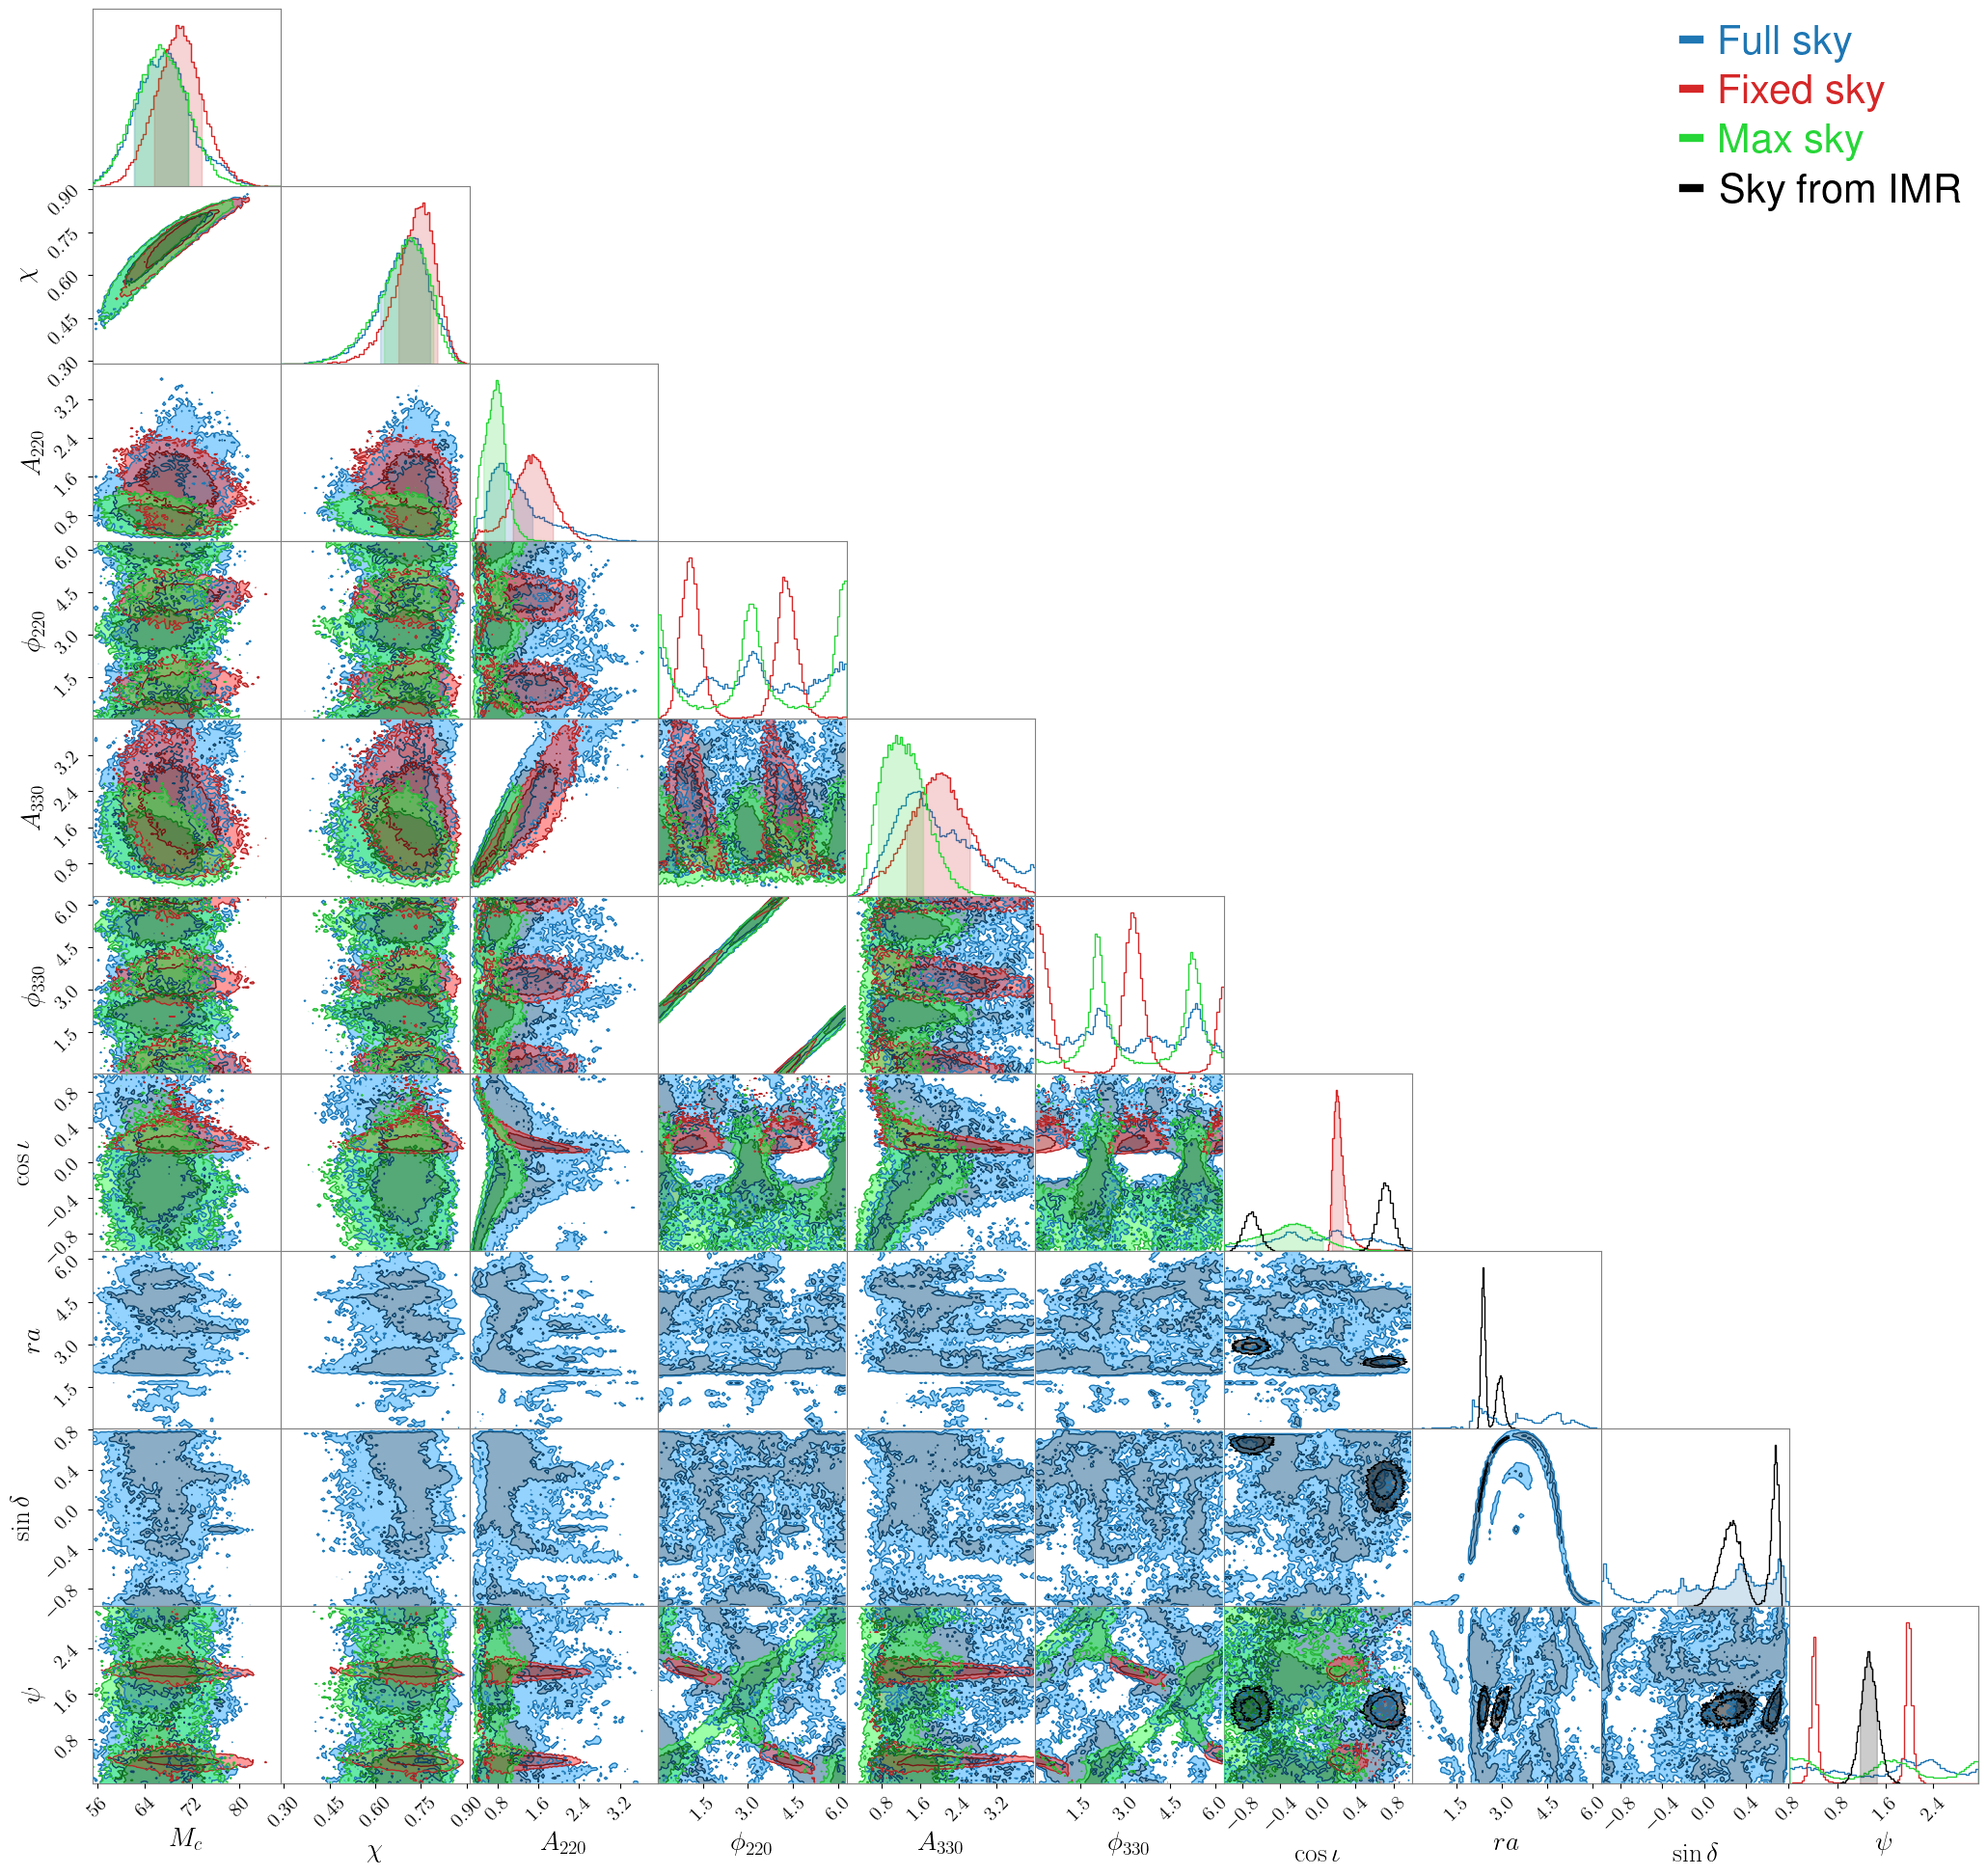

In [33]:
full_sky_params = [r'$M_c$', r'$\chi$', r'$A_{220}$', r'$\phi_{220}$', r'$A_{330}$', r'$\phi_{330}$', r'$\cos\iota$', r'$ra$', r'$\sin \delta$', r'$\psi$']
fixed_sky_params = [r'$M_c$', r'$\chi$', r'$A_{220}$', r'$\phi_{220}$', r'$A_{330}$', r'$\phi_{330}$', r'$\cos\iota$', r'$\psi$']
sky_params = [r'$\cos\iota$', r'$ra$', r'$\sin \delta$', r'$\psi$']

df_full_sky = pd.DataFrame(posterior_full_sky, columns=full_sky_params)
df_fixed_sky = pd.DataFrame(posterior_fixed_sky, columns=fixed_sky_params)
df_max_sky = pd.DataFrame(posterior_informed_sky['theta'], columns=fixed_sky_params)
df_IMR_sky_samples = pd.DataFrame(samples_IMR, columns=sky_params)

c = ChainConsumer()
c.add_chain(Chain(samples=df_full_sky, color='#1f77b4', name="Full sky"))
c.add_chain(Chain(samples=df_fixed_sky, color='#d62728', name="Fixed sky"))
c.add_chain(Chain(samples=df_max_sky, color="#27d638", name="Max sky"))
c.add_chain(Chain(samples=df_IMR_sky_samples, color='#000000', name="Sky from IMR"))
c.set_override(ChainConfig(sigmas=[0, 1, 2], bins=80, smooth=0,))
c.set_plot_config(
    PlotConfig(
        # flip=True,
        # labels=ns_parameters,
        summarise=0,
        usetex=1,
        contour_label_font_size=24,
        label_font_size=20,
        tick_font_size=15,
        legend_kwargs={'fontsize': 30}
    )
)
fig = c.plotter.plot()
# plt.savefig(corner_path, dpi=300, bbox_inches='tight')
plt.show()

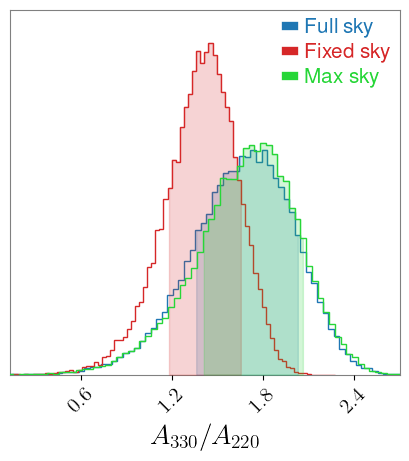

In [34]:
df_full_sky = pd.DataFrame(posterior_full_sky[:,4]/posterior_full_sky[:,2], columns=[r'$A_{330}/A_{220}$'])
df_fixed_sky = pd.DataFrame(posterior_fixed_sky[:,4]/posterior_fixed_sky[:,2], columns=[r'$A_{330}/A_{220}$'])
df_max_sky = pd.DataFrame(posterior_informed_sky['theta'][:,4]/posterior_informed_sky['theta'][:,2], columns=[r'$A_{330}/A_{220}$'])
# df_full_sky = pd.DataFrame(onp.imag(posterior_full_sky[:,4]*onp.exp(1.j*posterior_full_sky[:,5]))/onp.imag(posterior_full_sky[:,2]*onp.exp(1.j*posterior_full_sky[:,3])), columns=[r'$A_{330}/A_{220}$'])
# df_fixed_sky = pd.DataFrame(onp.imag(posterior_fixed_sky[:,4]*onp.exp(1.j*posterior_fixed_sky[:,5]))/onp.imag(posterior_fixed_sky[:,2]*onp.exp(1.j*posterior_fixed_sky[:,3])), columns=[r'$A_{330}/A_{220}$'])

c = ChainConsumer()
c.add_chain(Chain(samples=df_full_sky, color='#1f77b4', name="Full sky"))
c.add_chain(Chain(samples=df_fixed_sky, color='#d62728', name="Fixed sky"))
c.add_chain(Chain(samples=df_max_sky, color='#27d638', name="Max sky"))
c.set_override(ChainConfig(sigmas=[0, 1, 2], bins=80, smooth=0,))
c.set_plot_config(
    PlotConfig(
        # flip=True,
        # labels=ns_parameters,
        usetex=1,
        label_font_size=20,
        tick_font_size=15,
        contour_label_font_size=24,
        legend_kwargs={'fontsize': 15, 'loc': 'upper right'}
    )
)

fig = c.plotter.plot()
# plt.savefig('./plots/GW190521_amp_ratio_comp.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
limits = [
    [55.0, 95.0],
    [0., 0.99],
    [0., 4.0],
    [0., 6.283185307179586],
    [-1., 1.],
    [0., 3.141592653589793]]

low  = onp.asarray([pair[0] for pair in limits], dtype=onp.float64)
high = onp.asarray([pair[1] for pair in limits], dtype=onp.float64)

In [38]:
def make_loglik_fn(dataH, dataL, gmst, L_H, L_L,
                   omega_r, omega_i, omega_OT_r, omega_OT_i,
                   T, srate, t0):
    def _loglik(theta):
        return ln_likelihood_full_jit(
            dataH=dataH, dataL=dataL, params=theta,
            gmst=gmst, L_H=L_H, L_L=L_L,
            omega_r=omega_r, omega_i=omega_i,
            omega_OT_r=omega_OT_r, omega_OT_i=omega_OT_i,
            T=T, srate=srate, t0=t0
        )
    return _loglik

loglik_fn = make_loglik_fn(
    dataH=h_H_t, dataL=h_L_t,
    gmst=gmst, L_H=L_H, L_L=L_L,
    omega_r=omega_r, omega_i=omega_i,
    omega_OT_r=omega_OT_r, omega_OT_i=omega_OT_i,
    T=T, srate=srate, t0=t0
)

def loglike_220(theta_free):
    theta_free_batched = jnp.broadcast_to(theta_free, (nsamp, theta_free.shape[0]))  
    amp_phase_221_batched = jnp.broadcast_to(jnp.array([0.,0.]), (nsamp, 2))
    thetas_batched = jnp.concatenate(
                        [
                            theta_free_batched[:, :4],
                            amp_phase_221_batched,
                            theta_free_batched[:,4:5],
                            ext_mc_integ,              
                            theta_free_batched[:, 5:6],          
                        ],
                        axis=1,
                    )

    logliks = jax.vmap(loglik_fn)(thetas_batched)
    return logsumexp(logliks + logw_mc_integ)

In [39]:
def model_informed_sky_220():
    theta_free = numpyro.sample("theta", dist.Uniform(low, high))
    numpyro.factor("loglike", loglike_220(theta_free))

In [40]:
rng_key = jax.random.PRNGKey(int(seed) ^ 0xABCDEF)
rng_run, rng_post = jax.random.split(rng_key)
ns_informed_sky_220 = NestedSampler(
    model_informed_sky_220,
    constructor_kwargs=dict(
        num_live_points=10000,    
        max_samples=500_000,   
        verbose=True,
    ),
    termination_kwargs=dict(
        dlogZ=0.01,             
    ),
)
ns_informed_sky_220.run(rng_run)
ns_informed_sky_220.print_summary()
posterior_informed_sky_220 = ns_informed_sky_220.get_samples(rng_post, num_samples=100_000)

INFO:jaxns:Number of Markov-chains set to: 10000


Running over 12 devices.
Creating initial state with 10008 live points.
Running uniform sampling down to efficiency threshold of 0.1.
Running until termination condition: TerminationCondition(ess=None, evidence_uncert=None, live_evidence_frac=None, dlogZ=Array(0.01, dtype=float64, weak_type=True), max_samples=Array(500400, dtype=int64), max_num_likelihood_evaluations=None, log_L_contour=None, efficiency_threshold=None, rtol=None, atol=None, peak_XL_frac=None)
-------
Num samples: 5004
Num likelihood evals: 184907
Efficiency: 0.052698369236115865
log(L) contour: -1647.5756664071598
log(Z) est.: -749.3895423031579 +- 0.5848012061904765
log(Z | remaining) est.: 906.8095098837339 +- 0.7102417278411095
ESS: 1.2260923521830873

-------
Num samples: 10008
Num likelihood evals: 408892
Efficiency: 0.031502408007806355
log(L) contour: -964.511780007339
log(Z) est.: -747.2059773723533 +- 0.5484393227544831
log(Z | remaining) est.: 224.67829540499724 +- 0.5757936448600892
ESS: 1.4248269796594921



2026-04-28 18:08:51.049584: E external/xla/xla/service/rendezvous.cc:100] [id=0] This thread has been waiting for `all gather RendezvousKey{run_id=RunId: 1143555259, global_devices=[0,1,2,3,4,5,6,7,8,9,10,11], num_local_participants=12, collective_op_kind=cross_module, op_id=1}` for 5 seconds and may be stuck. Expected 12 threads to join the rendezvous, but not all of them arrived on time.
2026-04-28 18:08:57.943187: E external/xla/xla/service/rendezvous.cc:110] Thread is unstuck! Warning above was a false-positive. Perhaps the timeout is too short.


-------
Num samples: 45036
Num likelihood evals: 3166572
Efficiency: 0.010603065226650055
log(L) contour: -749.3051881992316
log(Z) est.: -743.996416436378 +- 0.1481094250294973
log(Z | remaining) est.: 12.013498172413165 +- 0.15068268702887566
ESS: 22.90523882625733

-------
Num samples: 50040
Num likelihood evals: 3727259
Efficiency: 0.009774878912808432
log(L) contour: -746.0291259100347
log(Z) est.: -743.7680072705396 +- 0.11714631893695437
log(Z | remaining) est.: 9.108957499594567 +- 0.11999132261236663
ESS: 37.2628649723941

-------
Num samples: 55044
Num likelihood evals: 4322293
Efficiency: 0.009125425360804438
log(L) contour: -743.5767787457653
log(Z) est.: -743.433793018343 +- 0.08320659544987596
log(Z | remaining) est.: 7.15181130735607 +- 0.08693453598325318
ESS: 76.9497452026154

-------
Num samples: 60048
Num likelihood evals: 4950732
Efficiency: 0.008568368439842914
log(L) contour: -741.6417788445883
log(Z) est.: -743.2143364143958 +- 0.060220530164361845
log(Z | remain

2026-04-28 19:14:33.245089: E external/xla/xla/service/rendezvous.cc:100] [id=0] This thread has been waiting for `all gather RendezvousKey{run_id=RunId: 1143555259, global_devices=[0,1,2,3,4,5,6,7,8,9,10,11], num_local_participants=12, collective_op_kind=cross_module, op_id=1}` for 5 seconds and may be stuck. Expected 12 threads to join the rendezvous, but not all of them arrived on time.
2026-04-28 19:14:33.245637: E external/xla/xla/service/rendezvous.cc:100] [id=1] This thread has been waiting for `all gather RendezvousKey{run_id=RunId: 1143555259, global_devices=[0,1,2,3,4,5,6,7,8,9,10,11], num_local_participants=12, collective_op_kind=cross_module, op_id=1}` for 5 seconds and may be stuck. Expected 12 threads to join the rendezvous, but not all of them arrived on time.
2026-04-28 19:14:38.545479: E external/xla/xla/service/rendezvous.cc:110] Thread is unstuck! Warning above was a false-positive. Perhaps the timeout is too short.
2026-04-28 19:14:38.545503: E external/xla/xla/serv

...

-------
Num samples: 105084
Num likelihood evals: 11628127
Efficiency: 0.0061808796636830705
log(L) contour: -733.102604351661
log(Z) est.: -742.2038790646978 +- 0.02895509773993461
log(Z | remaining) est.: 0.4178651712290957 +- 0.04050379407182301
ESS: 18277.936697170906



2026-04-28 20:05:50.087542: E external/xla/xla/service/rendezvous.cc:100] [id=0] This thread has been waiting for `all gather RendezvousKey{run_id=RunId: 1143555259, global_devices=[0,1,2,3,4,5,6,7,8,9,10,11], num_local_participants=12, collective_op_kind=cross_module, op_id=1}` for 5 seconds and may be stuck. Expected 12 threads to join the rendezvous, but not all of them arrived on time.
2026-04-28 20:06:03.730177: E external/xla/xla/service/rendezvous.cc:110] Thread is unstuck! Warning above was a false-positive. Perhaps the timeout is too short.


-------
Num samples: 110088
Num likelihood evals: 12515042
Efficiency: 0.005936168395478832
log(L) contour: -732.8486221996777
log(Z) est.: -742.1923853677885 +- 0.028975664158245294
log(Z | remaining) est.: 0.27667655588697926 +- 0.040653454442447945
ESS: 21713.92045130071

-------
Num samples: 115092
Num likelihood evals: 13435848
Efficiency: 0.00570693779563255
log(L) contour: -732.6578079714261
log(Z) est.: -742.1863274538543 +- 0.02898808119104498
log(Z | remaining) est.: 0.18056507200310534 +- 0.040765370271829755
ESS: 23920.58208801118

-------
Num samples: 120096
Num likelihood evals: 14393946
Efficiency: 0.005477928458517062
log(L) contour: -732.5178091727211
log(Z) est.: -742.1830003525838 +- 0.028995406672938474
log(Z | remaining) est.: 0.1165310660145451 +- 0.04084684146515952
ESS: 25113.718544354848



2026-04-28 20:41:36.086574: E external/xla/xla/service/rendezvous.cc:100] [id=0] This thread has been waiting for `all gather RendezvousKey{run_id=RunId: 1143555259, global_devices=[0,1,2,3,4,5,6,7,8,9,10,11], num_local_participants=12, collective_op_kind=cross_module, op_id=1}` for 5 seconds and may be stuck. Expected 12 threads to join the rendezvous, but not all of them arrived on time.
2026-04-28 20:41:43.092519: E external/xla/xla/service/rendezvous.cc:110] Thread is unstuck! Warning above was a false-positive. Perhaps the timeout is too short.


-------
Num samples: 125100
Num likelihood evals: 15388834
Efficiency: 0.005269820274274978
log(L) contour: -732.4156235280088
log(Z) est.: -742.1814574389535 +- 0.028998902137422195
log(Z | remaining) est.: 0.07431452072353295 +- 0.04090380893421728
ESS: 25685.479229314522

-------
Num samples: 130104
Num likelihood evals: 16420406
Efficiency: 0.005067090341846329
log(L) contour: -732.3372522087753
log(Z) est.: -742.1806266080043 +- 0.0290008193849803
log(Z | remaining) est.: 0.047072734801759 +- 0.040942868044902214
ESS: 25943.571644023054

-------
Num samples: 135108
Num likelihood evals: 17487910
Efficiency: 0.004891837503794253
log(L) contour: -732.2768935765893
log(Z) est.: -742.1802110467852 +- 0.029001786843938213
log(Z | remaining) est.: 0.029630544389874558 +- 0.04096898098200912
ESS: 26055.31915618603

-------
Num samples: 140112
Num likelihood evals: 18584160
Efficiency: 0.004744726777601362
log(L) contour: -732.2293848982567
log(Z) est.: -742.1799886313572 +- 0.02900230702

In [41]:
ns_informed_sky_220._results.log_Z_mean

Array(-745.54485204, dtype=float64)

In [42]:
ns_informed_sky._results.log_Z_mean - ns_informed_sky_220._results.log_Z_mean

Array(5.11627474, dtype=float64)